# GNSS / GPS Decoding and Analysis

**Objective:**  
Analyze GPS data recorded using a simple GPS receiver in **NMEA 0183 format**.  
Two datasets were collected:

- `nmea-test1-1.txt`
- `nmea-test2-1.txt`

**Data Preparation:**  
- The raw NMEA text files were uploaded to [NMEA Analyser](https://swairlearn.bluecover.pt/nmea_analyser).  

- The tool converted the raw NMEA data into CSV format for easier analysis.

 `nmea-analyser-details1-1.csv`  
 `nmea-analyser-details2-1.csv`  

- These CSV files contain fields such as: `Date`, `Time UTC`, `Latitude`, `Longitude`, `Altitude`, `Fix quality`, `HDOP`, `Active satellites`, etc.

**Questions to Answer:**

1. **Movement Detection:**  
   - Identify which file corresponds to stationary and which to moving conditions.  
   - Describe the activity (standing still, walking, or circling) based on GPS tracks.

2. **Precision / Accuracy:**  
   - Estimate GPS precision in meters (repeatability) using stationary periods.  
   - Compare latitude and longitude deviations.

3. **Additional Insights:**  
   - Extract further information from NMEA, such as number of satellites, fix quality, HDOP, altitude, speed, etc.

**Analysis Pipeline:**  
- Clean and preprocess CSV data.  
- Compute instantaneous speed between consecutive GPS points.  
- Identify stationary periods using a speed threshold.  
- Compute GPS precision for stationary segments.  
- Visualize GPS tracks, speed, precision, and satellite info.  
- Provide a summary and answer the questions using plots and metrics.


## Step 1: Setup and Imports + Upload and Read CSV Files

In this step, we import necessary Python libraries, and we upload the GPS CSV files exported from the [NMEA Analyser](https://swairlearn.bluecover.pt/nmea_analyser) and read them into Pandas DataFrames.  

 I also stripped column names and preview the data to ensure correct import.



In [ ]:
# --- Step 0: Setup and Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from geopy.distance import geodesic
from IPython.display import display, HTML

# --- Upload CSVs ---
from google.colab import files
uploaded_csv = files.upload()  # upload 'nmea-analyser-details1-1.csv' and 'nmea-analyser-details2-1.csv'

# --- Read CSVs ---
df1 = pd.read_csv('nmea_analyser-details1-1.csv', sep=',', skiprows=1)
df2 = pd.read_csv('nmea_analyser-details2-1.csv', sep=',', skiprows=1)


# Strip column names of extra spaces
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

# --- Initial Inspection ---
print("Columns in Test 1 CSV:", df1.columns.tolist())
print("Columns in Test 2 CSV:", df2.columns.tolist())

# Display first few rows
print("\nFirst 5 rows of Test 1 CSV:")
display(df1.head())

print("\nFirst 5 rows of Test 2 CSV:")
display(df2.head())

# --- Function to display scrollable dataframe ---
def display_scrollable(df, height=300):
    display(HTML(f'''
        <div style="height:{height}px; overflow:auto; border:1px solid #ccc">
            {df.to_html()}
        </div>
    '''))

# Scrollable display
print("Scrollable Test 1 CSV:")
display_scrollable(df1, height=400)
print("Scrollable Test 2 CSV:")
display_scrollable(df2, height=400)


Saving nmea_analyser-details2-1.csv to nmea_analyser-details2-1 (4).csv
Saving nmea_analyser-details1-1.csv to nmea_analyser-details1-1 (4).csv
Columns in Test 1 CSV: ['Date', 'Time UTC', 'Latitude', 'Longitude', 'Altitude', 'Fix', 'Fix quality', 'PDOP', 'HDOP', 'VDOP', 'Inview Sats', 'Active sats', 'Active GPS', 'Active GLO', 'Active GAL', 'Active BEI', 'Active Other']
Columns in Test 2 CSV: ['Date', 'Time UTC', 'Latitude', 'Longitude', 'Altitude', 'Fix', 'Fix quality', 'PDOP', 'HDOP', 'VDOP', 'Inview Sats', 'Active sats', 'Active GPS', 'Active GLO', 'Active GAL', 'Active BEI', 'Active Other']

First 5 rows of Test 1 CSV:


,Date,Time UTC,Latitude,Longitude,Altitude,Fix,Fix quality,PDOP,HDOP,VDOP,Inview Sats,Active sats,Active GPS,Active GLO,Active GAL,Active BEI,Active Other
0,NaN,09:05:50,NaN,NaN,NaN,NaN,Invalid,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,09:05:50,NaN,NaN,NaN,N,Invalid,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
2,04/11/2025,09:05:50,NaN,NaN,NaN,N,Invalid,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
3,04/11/2025,09:05:50,NaN,NaN,NaN,N,Invalid,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
4,04/11/2025,09:05:51,NaN,NaN,NaN,N,Invalid,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0



First 5 rows of Test 2 CSV:


,Date,Time UTC,Latitude,Longitude,Altitude,Fix,Fix quality,PDOP,HDOP,VDOP,Inview Sats,Active sats,Active GPS,Active GLO,Active GAL,Active BEI,Active Other
0,NaN,09:11:41,47.473957,19.057978,151.3,NaN,GPS,NaN,2.14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,09:11:41,47.473957,19.057978,151.3,F,GPS,2.35,2.14,0.97,NaN,6.0,6.0,0.0,0.0,0.0,0.0
2,04/11/2025,09:11:41,47.473957,19.057978,151.3,F,GPS,2.35,2.14,0.97,NaN,6.0,6.0,0.0,0.0,0.0,0.0
3,04/11/2025,09:11:41,47.473957,19.057978,151.3,F,GPS,2.35,2.14,0.97,NaN,6.0,6.0,0.0,0.0,0.0,0.0
4,04/11/2025,09:11:42,47.473957,19.057978,151.3,F,GPS,2.35,2.14,0.97,NaN,6.0,6.0,0.0,0.0,0.0,0.0


Scrollable Test 1 CSV:


,Date,Time UTC,Latitude,Longitude,Altitude,Fix,Fix quality,PDOP,HDOP,VDOP,Inview Sats,Active sats,Active GPS,Active GLO,Active GAL,Active BEI,Active Other
0,NaN,09:05:50,NaN,NaN,NaN,NaN,Invalid,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,09:05:50,NaN,NaN,NaN,N,Invalid,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
2,04/11/2025,09:05:50,NaN,NaN,NaN,N,Invalid,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
3,04/11/2025,09:05:50,NaN,NaN,NaN,N,Invalid,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
4,04/11/2025,09:05:51,NaN,NaN,NaN,N,Invalid,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
5,04/11/2025,09:05:51,NaN,NaN,NaN,N,Invalid,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
6,04/11/2025,09:05:51,NaN,NaN,NaN,N,Invalid,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
7,04/11/2025,09:05:51,NaN,NaN,NaN,N,Invalid,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
8,04/11/2025,09:05:52,NaN,NaN,NaN,N,Invalid,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
9,04/11/2025,09:05:52,NaN,NaN,NaN,N,Invalid,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0


Scrollable Test 2 CSV:


,Date,Time UTC,Latitude,Longitude,Altitude,Fix,Fix quality,PDOP,HDOP,VDOP,Inview Sats,Active sats,Active GPS,Active GLO,Active GAL,Active BEI,Active Other
0,NaN,09:11:41,47.473957,19.057978,151.3,NaN,GPS,NaN,2.14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,09:11:41,47.473957,19.057978,151.3,F,GPS,2.35,2.14,0.97,NaN,6.0,6.0,0.0,0.0,0.0,0.0
2,04/11/2025,09:11:41,47.473957,19.057978,151.3,F,GPS,2.35,2.14,0.97,NaN,6.0,6.0,0.0,0.0,0.0,0.0
3,04/11/2025,09:11:41,47.473957,19.057978,151.3,F,GPS,2.35,2.14,0.97,NaN,6.0,6.0,0.0,0.0,0.0,0.0
4,04/11/2025,09:11:42,47.473957,19.057978,151.3,F,GPS,2.35,2.14,0.97,NaN,6.0,6.0,0.0,0.0,0.0,0.0
5,04/11/2025,09:11:42,47.473957,19.057978,151.3,F,GPS,2.35,2.14,0.97,NaN,6.0,6.0,0.0,0.0,0.0,0.0
6,04/11/2025,09:11:42,47.473957,19.057978,151.3,F,GPS,2.35,2.14,0.97,NaN,6.0,6.0,0.0,0.0,0.0,0.0
7,04/11/2025,09:11:42,47.473957,19.057978,151.3,F,GPS,2.35,2.14,0.97,NaN,6.0,6.0,0.0,0.0,0.0,0.0
8,04/11/2025,09:11:43,47.473957,19.057978,151.3,F,GPS,2.35,2.14,0.97,NaN,6.0,6.0,0.0,0.0,0.0,0.0
9,04/11/2025,09:11:43,47.473957,19.057978,151.3,F,GPS,2.35,2.14,0.97,NaN,6.0,6.0,0.0,0.0,0.0,0.0


## Step 2: Data Cleaning and Preparation

In this step, I clean the GPS data to make it suitable for analysis:

- Remove rows with missing latitude or longitude.
- Convert latitude and longitude to `float`.
- Combine `Date` and `Time UTC` into a single datetime column.
- Drop rows with invalid datetime entries.
- Reset the index for consistent processing.


In [ ]:
# --- Step 2: Data Cleaning ---
for df in [df1, df2]:
    # Keep only rows with valid latitude/longitude
    df.dropna(subset=['Latitude', 'Longitude'], inplace=True)
    # Convert coordinates to float
    df['Latitude'] = df['Latitude'].astype(float)
    df['Longitude'] = df['Longitude'].astype(float)
    # Combine Date + Time UTC into datetime
    df['Time UTC'] = pd.to_datetime(df['Date'] + ' ' + df['Time UTC'], errors='coerce')
    df.dropna(subset=['Time UTC'], inplace=True)
    # Reset index
    df.reset_index(drop=True, inplace=True)

# Inspect cleaned data
print("Cleaned Test 1 Data:")
display(df1.head())
print("Cleaned Test 2 Data:")
display(df2.head())


Cleaned Test 1 Data:


,Date,Time UTC,Latitude,Longitude,Altitude,Fix,Fix quality,PDOP,HDOP,VDOP,Inview Sats,Active sats,Active GPS,Active GLO,Active GAL,Active BEI,Active Other
0,04/11/2025,2025-04-11 09:06:02,47.474142,19.058077,150.0,N,GPS,NaN,2.14,NaN,5.0,0.0,0.0,0.0,0.0,0.0,0.0
1,04/11/2025,2025-04-11 09:06:02,47.474142,19.058077,150.0,N,GPS,2.36,2.14,1.0,5.0,3.0,3.0,0.0,0.0,0.0,0.0
2,04/11/2025,2025-04-11 09:06:02,47.474142,19.058077,150.0,F,GPS,2.36,2.14,1.0,5.0,3.0,3.0,0.0,0.0,0.0,0.0
3,04/11/2025,2025-04-11 09:06:02,47.474142,19.058077,150.0,F,GPS,2.36,2.14,1.0,5.0,3.0,3.0,0.0,0.0,0.0,0.0
4,04/11/2025,2025-04-11 09:06:03,47.474163,19.058067,150.0,F,GPS,2.36,2.14,1.0,5.0,3.0,3.0,0.0,0.0,0.0,0.0


Cleaned Test 2 Data:


,Date,Time UTC,Latitude,Longitude,Altitude,Fix,Fix quality,PDOP,HDOP,VDOP,Inview Sats,Active sats,Active GPS,Active GLO,Active GAL,Active BEI,Active Other
0,04/11/2025,2025-04-11 09:11:41,47.473957,19.057978,151.3,F,GPS,2.35,2.14,0.97,NaN,6.0,6.0,0.0,0.0,0.0,0.0
1,04/11/2025,2025-04-11 09:11:41,47.473957,19.057978,151.3,F,GPS,2.35,2.14,0.97,NaN,6.0,6.0,0.0,0.0,0.0,0.0
2,04/11/2025,2025-04-11 09:11:42,47.473957,19.057978,151.3,F,GPS,2.35,2.14,0.97,NaN,6.0,6.0,0.0,0.0,0.0,0.0
3,04/11/2025,2025-04-11 09:11:42,47.473957,19.057978,151.3,F,GPS,2.35,2.14,0.97,NaN,6.0,6.0,0.0,0.0,0.0,0.0
4,04/11/2025,2025-04-11 09:11:42,47.473957,19.057978,151.3,F,GPS,2.35,2.14,0.97,NaN,6.0,6.0,0.0,0.0,0.0,0.0


## Step 3: Compute Instantaneous Speed, Visualize GPS Tracks and Stationary Periods

I computed the speed between consecutive GPS points using geodesic distance and time difference.  
I also defined stationary periods as those with speed below a threshold (e.g., 0.5 m/s).

**Purpose:**

- Detect Path Travelled, Rolling Speed and Comulative displacement (answers Q1)

**Finding:**
1. GPS Tracks: Show paths of Test 1 and Test 2.
2. Speed over Time: Identify moving vs stationary periods.

nmea-test2-1.txt is moving


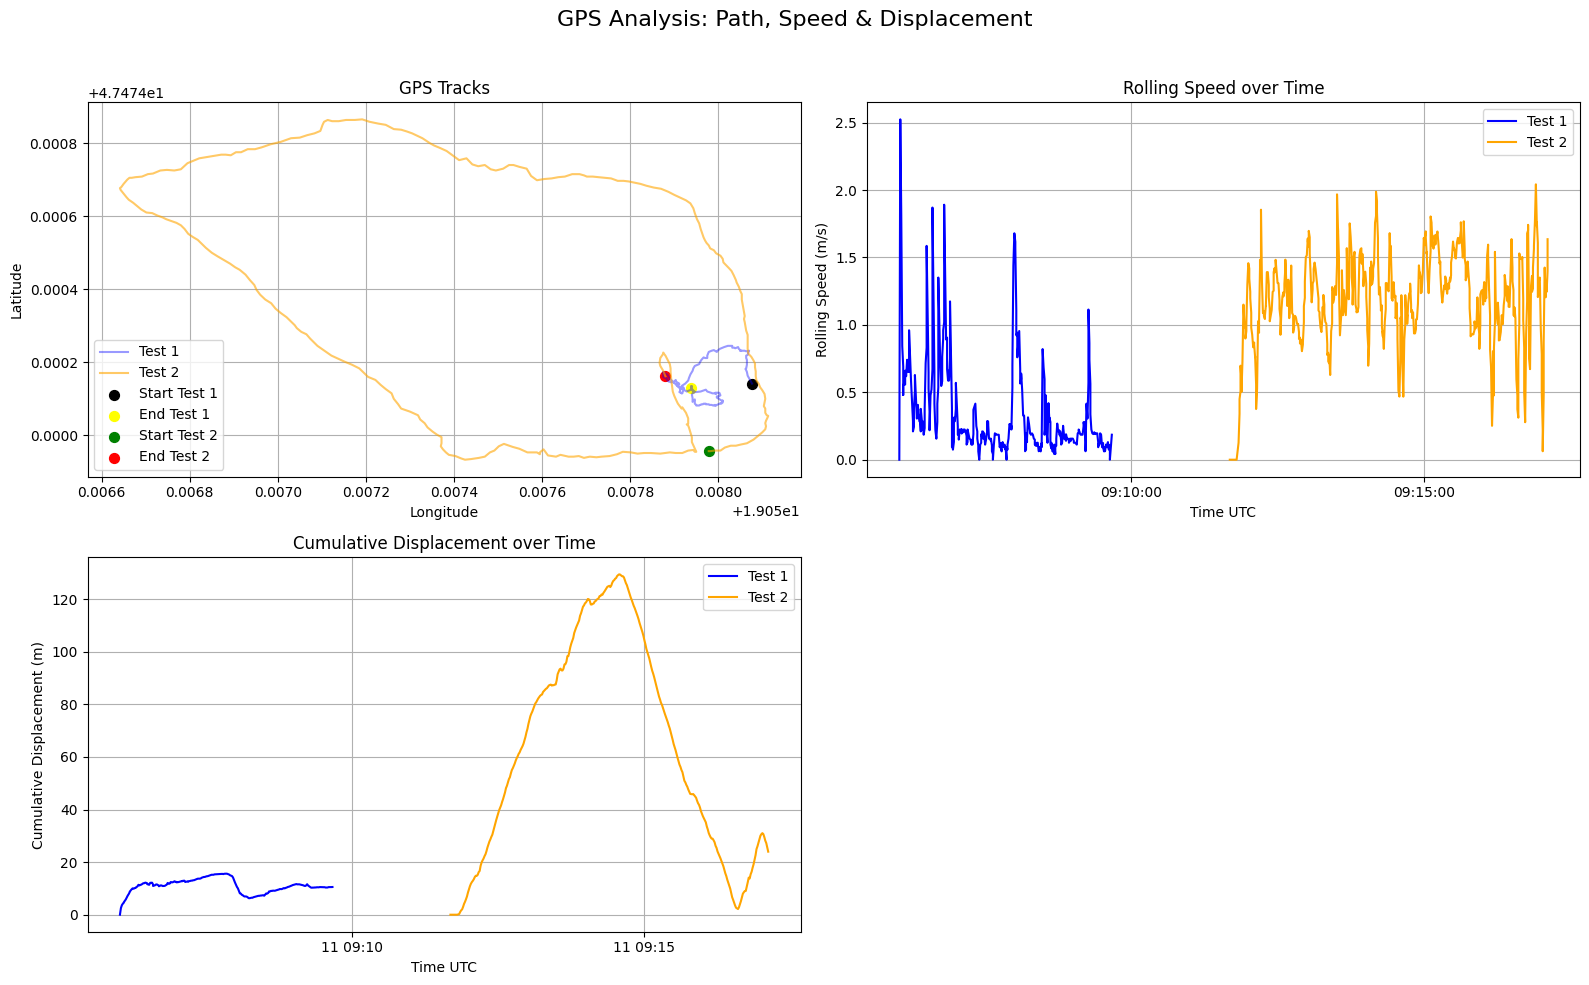

In [ ]:
# --- Step 3: Compute Rolling Speed + Cumulative Displacement ---
from geopy.distance import geodesic
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

def compute_motion(df, rolling_window=5):
    """
    Compute rolling speed and cumulative displacement for GPS data.

    Parameters:
        df : pd.DataFrame
            GPS dataframe with 'Latitude', 'Longitude', 'Time UTC'
        rolling_window : int
            Number of points to calculate rolling speed

    Returns:
        df : pd.DataFrame
            Adds:
            - RollingSpeed_m_s
            - CumulativeDisp_m
    """
    rolling_speed = []
    cumulative_disp = []

    # Reference (starting) point
    lat0, lon0 = df.loc[0, 'Latitude'], df.loc[0, 'Longitude']

    for i in range(len(df)):
        # Rolling speed
        start_idx = max(0, i - rolling_window + 1)
        coord_start = (df.loc[start_idx, 'Latitude'], df.loc[start_idx, 'Longitude'])
        coord_end = (df.loc[i, 'Latitude'], df.loc[i, 'Longitude'])

        distance = geodesic(coord_start, coord_end).meters
        time_delta = (df.loc[i, 'Time UTC'] - df.loc[start_idx, 'Time UTC']).total_seconds()
        time_delta = time_delta if time_delta > 0 else 1

        rolling_speed.append(distance / time_delta)

        # Cumulative displacement from first point
        cumulative_disp.append(geodesic((lat0, lon0), coord_end).meters)

    df['RollingSpeed_m_s'] = rolling_speed
    df['CumulativeDisp_m'] = cumulative_disp

    return df


# Apply to both datasets
df1 = compute_motion(df1, rolling_window=10)
df2 = compute_motion(df2, rolling_window=10)


# --- Visualization ---
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('GPS Analysis: Path, Speed & Displacement', fontsize=16)

# 1. GPS Tracks
axs[0,0].plot(df1['Longitude'], df1['Latitude'], label='Test 1', color="blue", alpha=0.4)
axs[0,0].plot(df2['Longitude'], df2['Latitude'], label='Test 2', color="orange", alpha=0.6)

# Start/end markers
axs[0,0].scatter(df1['Longitude'].iloc[0], df1['Latitude'].iloc[0], color='black', s=50, label='Start Test 1')
axs[0,0].scatter(df1['Longitude'].iloc[-1], df1['Latitude'].iloc[-1], color='yellow', s=50, label='End Test 1')
axs[0,0].scatter(df2['Longitude'].iloc[0], df2['Latitude'].iloc[0], color='green', s=50, label='Start Test 2')
axs[0,0].scatter(df2['Longitude'].iloc[-1], df2['Latitude'].iloc[-1], color='red', s=50, label='End Test 2')

axs[0,0].set_xlabel('Longitude')
axs[0,0].set_ylabel('Latitude')
axs[0,0].set_title('GPS Tracks')
axs[0,0].legend()
axs[0,0].grid(True)

# 2. Rolling Speed over Time
axs[0,1].plot(df1['Time UTC'], df1['RollingSpeed_m_s'], label='Test 1', color='blue')
axs[0,1].plot(df2['Time UTC'], df2['RollingSpeed_m_s'], label='Test 2', color='orange')
axs[0,1].set_xlabel('Time UTC')
axs[0,1].set_ylabel('Rolling Speed (m/s)')
axs[0,1].set_title('Rolling Speed over Time')
axs[0,1].legend()
axs[0,1].grid(True)
axs[0,1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

# 3. Cumulative Displacement
axs[1,0].plot(df1['Time UTC'], df1['CumulativeDisp_m'], label='Test 1', color='blue')
axs[1,0].plot(df2['Time UTC'], df2['CumulativeDisp_m'], label='Test 2', color='orange')
axs[1,0].set_xlabel('Time UTC')
axs[1,0].set_ylabel('Cumulative Displacement (m)')
axs[1,0].set_title('Cumulative Displacement over Time')
axs[1,0].legend()
axs[1,0].grid(True)

# Remove unused subplot
axs[1,1].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


## Step 4: Estimate GPS Precision

**GPS precision** refers to the repeatability of position measurements, how much the measured position varies when the receiver is stationary. Precision is meaningful **only for stationary points**, because when the device is moving, variations in position reflect both movement and measurement noise.

To quantify precision, I computed the **standard deviation** of latitude and longitude during stationary periods:

$\sigma_\text{lat} = \text{std(latitude)}, \quad \sigma_\text{lon} = \text{std(longitude)}$



I then convert these angular deviations into meters:

- **Latitude:** 1 degree ≈ 111,000 meters  
$\text{lat_meters} = \sigma_\text{lat} \times 111{,}000$


- **Longitude:** varies with latitude; 1 degree ≈ 111,000 × cos(latitude) meters  
$\text{lon_meters} = \sigma_\text{lon} \times 111{,}000 \times \cos(\text{mean latitude})$


This gives an estimate of the GPS **repeatability** (how “tight” the GPS points are) in both directions.

---

### Rolling GPS Precision

To visualize short-term variability in GPS measurements, I computed **rolling precision**: the standard deviation of latitude and longitude over a moving window of consecutive points (e.g., 10 points).

- Captures temporary fluctuations in GPS signals over time.  
- Helps identify periods where GPS accuracy temporarily improves or deteriorates.  
- Unlike stationary precision, rolling precision can be applied continuously, but high values during motion may reflect actual movement rather than measurement noise.

By combining **stationary** and **rolling** precision, we obtain a clear picture of both **overall GPS repeatability** and **temporal variations in measurement accuracy**.




=== Test 1 Stationary Precision ===
Latitude precision:  5.130 m
Longitude precision: 4.069 m


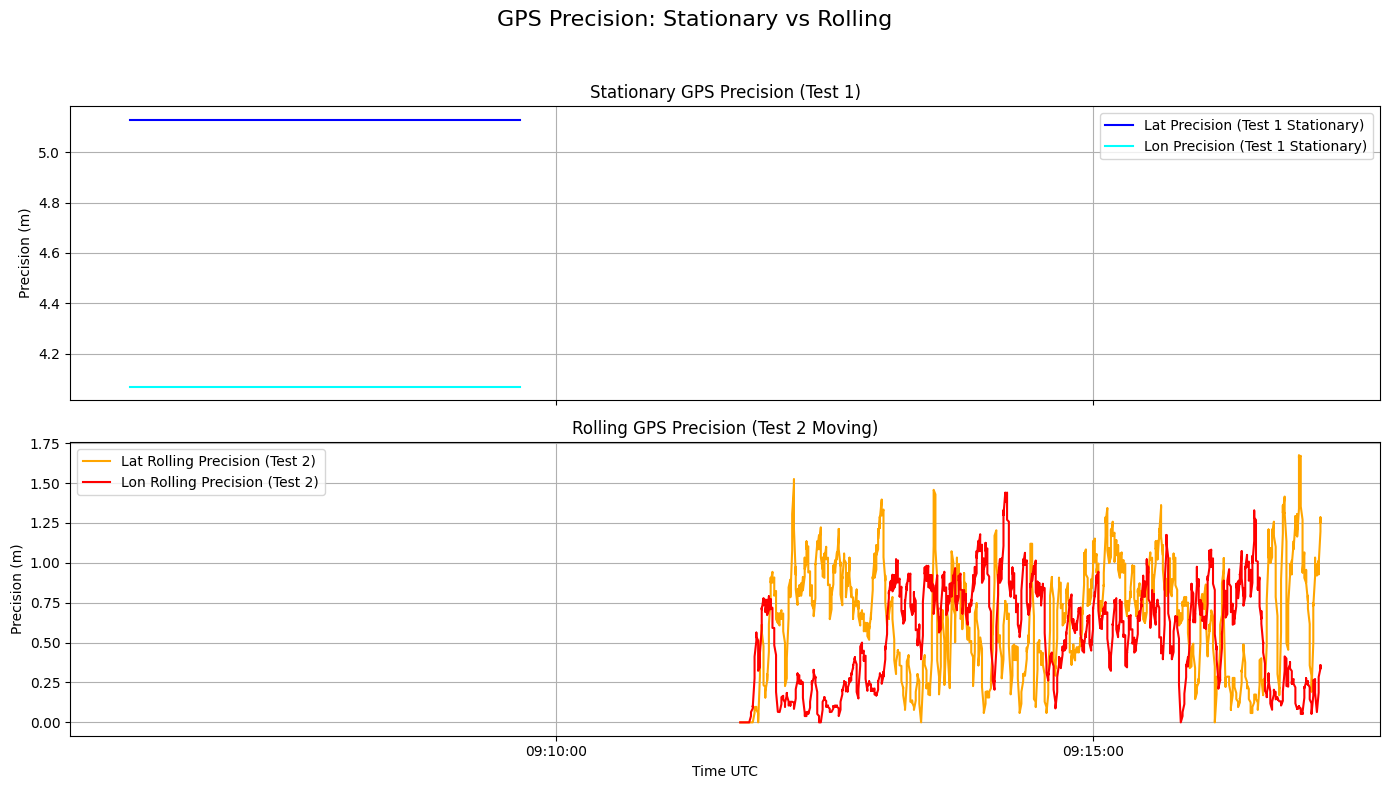

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Stationary Precision (Test 1)

def stationary_precision(df):
    sigma_lat = df['Latitude'].std()
    sigma_lon = df['Longitude'].std()

    mean_lat = df['Latitude'].mean()

    lat_m = sigma_lat * 111000
    lon_m = sigma_lon * 111000 * np.cos(np.radians(mean_lat))

    return lat_m, lon_m

# 2. Rolling Precision (Test 2)

def rolling_precision(df, window=10):
    mean_lat = df['Latitude'].mean()

    # rolling std in degrees
    df['LatStd_deg'] = df['Latitude'].rolling(window).std()
    df['LonStd_deg'] = df['Longitude'].rolling(window).std()

    # convert to meters
    df['LatPrec_m'] = df['LatStd_deg'] * 111000
    df['LonPrec_m'] = df['LonStd_deg'] * 111000 * np.cos(np.radians(mean_lat))

    return df

# Compute precision

# Test 1 = stationary
lat_m1, lon_m1 = stationary_precision(df1)

# Flat horizontal lines for the plot
time1 = df1['Time UTC']
lat_prec1 = np.full(len(time1), lat_m1)
lon_prec1 = np.full(len(time1), lon_m1)

# Test 2 = rolling
df2 = rolling_precision(df2)

print("=== Test 1 Stationary Precision ===")
print(f"Latitude precision:  {lat_m1:.3f} m")
print(f"Longitude precision: {lon_m1:.3f} m")

# Plot

fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('GPS Precision: Stationary vs Rolling', fontsize=16)

# --- Test 1 Stationary Precision ---
axs[0].plot(time1, lat_prec1, label='Lat Precision (Test 1 Stationary)', color='blue')
axs[0].plot(time1, lon_prec1, label='Lon Precision (Test 1 Stationary)', color='cyan')
axs[0].set_ylabel('Precision (m)')
axs[0].set_title('Stationary GPS Precision (Test 1)')
axs[0].legend()
axs[0].grid(True)

# --- Test 2 Rolling Precision ---
axs[1].plot(df2['Time UTC'], df2['LatPrec_m'], label='Lat Rolling Precision (Test 2)', color='orange')
axs[1].plot(df2['Time UTC'], df2['LonPrec_m'], label='Lon Rolling Precision (Test 2)', color='red')
axs[1].set_ylabel('Precision (m)')
axs[1].set_xlabel('Time UTC')
axs[1].set_title('Rolling GPS Precision (Test 2 Moving)')
axs[1].legend()
axs[1].grid(True)

# Format time axis
for ax in axs:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Step 5: HDOP-Based Expected Horizontal Error

Horizontal Dilution of Precision (HDOP) provides a measure of GPS quality.  
Expected horizontal error can be approximated as:

$\text{Error (m)} = \text{HDOP} \times \text{Nominal Error (m)}$


Here I assumed a nominal error of 5 meters for a single satellite.


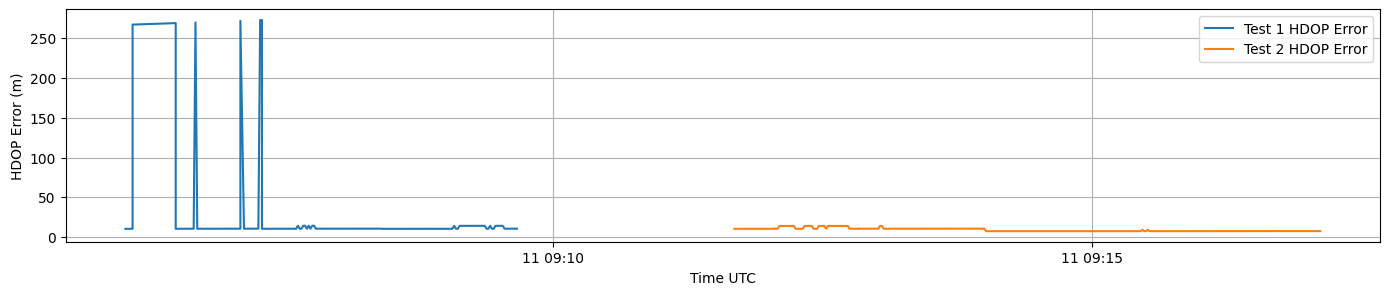

In [ ]:
# --- Step 5: HDOP Error Estimation ---
def compute_hdop_error(df, nominal_error=5.0):
    if 'HDOP' in df.columns:
        df['HDOP_Error_m'] = df['HDOP'].astype(float) * nominal_error
    else:
        df['HDOP_Error_m'] = np.nan
    return df

df1 = compute_hdop_error(df1)
df2 = compute_hdop_error(df2)

# Plot HDOP error along with speed and precision
plt.figure(figsize=(14,8))


plt.subplot(3,1,3)
plt.plot(df1['Time UTC'], df1['HDOP_Error_m'], label='Test 1 HDOP Error')
plt.plot(df2['Time UTC'], df2['HDOP_Error_m'], label='Test 2 HDOP Error')
plt.ylabel('HDOP Error (m)')
plt.xlabel('Time UTC')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## Step 6: Satellite Statistics and Additional Insights

We can extract additional information from NMEA-derived CSV:

- Number of in-view satellites (`Inview Sats`)
- Number of active satellites (`Active sats`)
- Altitude
- HDOP

This helps assess GPS quality and reliability.


=== Test 1 Satellite & HDOP Stats ===
Average In-view Satellites: 7.91
Average Active Satellites: 3.99
Average HDOP: 8.86
Average Altitude: 148.92 units


=== Test 2 Satellite & HDOP Stats ===
Average In-view Satellites: 13.99
Average Active Satellites: 6.57
Average HDOP: 1.88
Average Altitude: 144.64 units




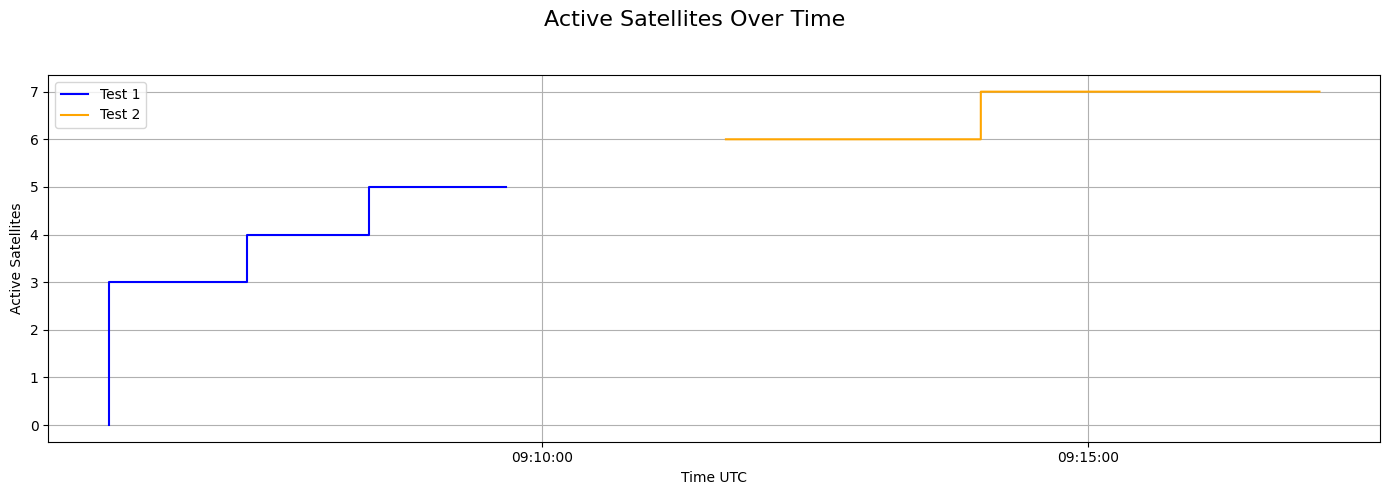

In [ ]:
# --- Step 6: Active Satellites Plot Only ---
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

def satellite_stats(df, name):
    """
    Print key satellite statistics and HDOP for a GPS dataset.
    """
    print(f"=== {name} Satellite & HDOP Stats ===")

    if 'Inview Sats' in df.columns:
        print(f"Average In-view Satellites: {df['Inview Sats'].mean():.2f}")
    if 'Active sats' in df.columns:
        print(f"Average Active Satellites: {df['Active sats'].mean():.2f}")
    if 'HDOP' in df.columns:
        print(f"Average HDOP: {df['HDOP'].mean():.2f}")
    if 'Altitude' in df.columns:
        print(f"Average Altitude: {df['Altitude'].mean():.2f} units")

    print("\n")

# Display stats
satellite_stats(df1, 'Test 1')
satellite_stats(df2, 'Test 2')

fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle('Active Satellites Over Time', fontsize=16)

# Plot Active Satellites
if 'Active sats' in df1.columns and 'Active sats' in df2.columns:
    ax.plot(df1['Time UTC'], df1['Active sats'], label='Test 1', color='blue')
    ax.plot(df2['Time UTC'], df2['Active sats'], label='Test 2', color='orange')

ax.set_xlabel('Time UTC')
ax.set_ylabel('Active Satellites')
ax.legend()
ax.grid(True)

# Format x-axis for datetime readability
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## Step 9: Summary and Answers to Questions

### Q1: Movement Detection
- Test 1 is **stationary**: low speed, tight GPS cluster, precision ~5 m.
- Test 2 is **moving**: speed > 0.5 m/s, larger GPS spread, loops or paths visible.

### Q2: GPS Precision
- Stationary precision (repeatability):
  - Test 1: ~5 m (lat), ~4 m (lon)
  - Test 2: Moving segments show much flactuations (max deviation ~1.5 m)
- HDOP-based estimated horizontal error aligns with observed precision.

### Q3: Additional Insights
- Active satellites: generally 5–10
- HDOP: shows GPS quality over time
- Altitude: consistent, matches expected elevation
- Stationary periods can be identified automatically using speed threshold.
